# Sensitivity Analysis for Energy Calibration

This notebook walks through **`sisepuede/calibration/sensitivity.py`** step by step. All the real logic lives in that module; here we just call it to see each piece in action.

**What is tested here:**
1. Setup — imports, paths, baseline model run
2. Single-variable manual test (`perturb_inputs` and `perturb_inputs_simplex` standalone)
3. OAT — single variable
4. OAT — multiple variables
5. LHS — single variable
6. LHS — multiple variables
7. Sensitivity scores (Spearman rank correlation)
8. Linearity check (scatter + residual plot)

**Order of use for the actual analysis:**
1. Run OAT to quickly screen which variables matter.
2. Run LHS on the sensitive subset. The result of this can double as surrogate training data.
3. Use `linearity_check` to decide whether linear calibration or an optimiser is needed.

> **Simplex groups:** Fuel-fraction variables (e.g. `frac_inen_energy_cement_coal`)
> belong to simplex groups that must sum to 1 within each industry category.
> Setting `is_simplex_group=True` on a `VariableSpec` activates simplex-aware
> perturbation: all scale factors for the same constraint are applied simultaneously
> via renormalization (`desired_i = original_i × scale_i`, then divide by the row sum)
> so the constraint is always satisfied and each variable's Spearman score is
> independently interpretable.

---
## 1. Setup

In [30]:
import warnings
warnings.filterwarnings("ignore")

import sys
# Add the sisepuede repo root so local edits take precedence over the installed package
path = "/Users/dianamendez/feature-energy-calibration"
if path not in sys.path:
    sys.path.insert(0, path)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sisepuede.manager.sisepuede_file_structure import SISEPUEDEFileStructure
from sisepuede.calibration.iea_crosswalk        import IEACrosswalk
from sisepuede.calibration.iea_data_loader      import IEADataLoader
from sisepuede.calibration.sensitivity          import (
    VariableSpec,
    perturb_inputs,           # scalar perturbation (any variable)
    perturb_inputs_simplex,   # simplex-aware perturbation (fuel fractions)
    apply_perturbations,      # routes scalar vs simplex automatically
    sample_oat,
    sample_lhs,
    SensitivityRunner,
    sensitivity_scores,
    linearity_check,
)

# ── Paths — change these ─────────────────────────────────────────────────────
PATH_SISEPUEDE_INPUT = "/Users/dianamendez/sisepuede-data/input_data_peru_base.csv"
PATH_IEA_DATA_DIR    = "/Users/dianamendez/data_collection_temporary"
PATH_CROSSWALK_FILE  = "/Users/dianamendez/feature-energy-calibration/sisepuede/ref/data_crosswalks/sisepuede_iea_energy_crosswalk.csv"
ISO_COUNTRY          = "LBY"
END_YEAR             = 2022   # rows beyond this year are projections, not actuals
START_YEAR           = 2015   # first year included in the comparison window
TARGET_YEARS         = [2015] # calendar year(s) used when scoring/plotting
# ─────────────────────────────────────────────────────────────────────────────

file_struct      = SISEPUEDEFileStructure()
model_attributes = file_struct.model_attributes
print("model_attributes loaded")

model_attributes loaded


---
### Load inputs and build models

`EnergyConsumption` depends on outputs from `AFOLU` and `IPPU`, so we construct all three and keep the merged upstream output for merging.

In [31]:
from sisepuede.models.afolu              import AFOLU
from sisepuede.models.energy_consumption import EnergyConsumption
from sisepuede.models.ippu               import IPPU
from sisepuede.manager.sisepuede_models  import SISEPUEDEModels

# ── Build sector models ───────────────────────────────────────────────────────
model_afolu     = AFOLU            (model_attributes)
model_ippu      = IPPU             (model_attributes)
model_energycon = EnergyConsumption(model_attributes)

# ── Load input CSV ────────────────────────────────────────────────────────────
df_input_raw = pd.read_csv(PATH_SISEPUEDE_INPUT)

df_input = pd.read_csv(PATH_SISEPUEDE_INPUT)
df_input['year'] = range(2015,2015+len(df_input))
col = df_input.pop('year')
df_input.insert(0, 'year', col)

# Keep only rows up to the last year of actual observed data
df_input = df_input.loc[df_input["year"] <= END_YEAR].copy()
df_input = df_input.reset_index(drop=True)

print(f"Input shape: {df_input.shape}  |  years: {df_input['year'].min()}–{df_input['year'].max()}")

Input shape: (8, 2420)  |  years: 2015–2022


In [32]:
# Run upstream models (AFOLU + IPPU) so EnergyConsumption has their outputs
df_out_afolu = model_afolu(df_input)
df_out_ippu  = model_ippu (df_input)

# Merge upstream outputs into the input frame that EnergyConsumption will see
df_input_energy = df_input.merge(df_out_afolu, on="time_period", how="left", suffixes=("", "_afolu"))
df_input_energy = df_input_energy.merge(df_out_ippu,  on="time_period", how="left", suffixes=("", "_ippu"))

print(f"Merged input shape: {df_input_energy.shape}")
display(df_input_energy.head())

Merged input shape: (8, 3075)


,year,ef_ippu_tonne_nf3_per_tonne_production_chemicals,ef_ippu_tonne_nf3_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_mmm_gdp_other_product_manufacturing,ef_ippu_tonne_sf6_per_tonne_production_chemicals,ef_ippu_tonne_sf6_per_tonne_production_electronics,ef_ippu_tonne_sf6_per_tonne_production_metals,frac_agrc_bevs_and_spices_cl2_dry,frac_agrc_cereals_cl2_dry,frac_agrc_fibers_cl2_dry,...,prod_ippu_textiles_tonne,prod_ippu_wood_tonne,qty_ippu_recycled_glass_used_in_production_tonne,qty_ippu_recycled_metals_used_in_production_tonne,qty_ippu_recycled_paper_used_in_production_tonne,qty_ippu_recycled_plastic_used_in_production_tonne,qty_ippu_recycled_rubber_and_leather_used_in_production_tonne,qty_ippu_recycled_textiles_used_in_production_tonne,qty_ippu_recycled_wood_used_in_production_tonne,emission_co2e_subsector_total_ippu
0,2015,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,191616.390890,1.833323e+07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,29.935176
1,2016,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,296766.760296,1.869566e+07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,37.290638
2,2017,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,0.000000,1.893106e+07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,23.618600
3,2018,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,0.000000,1.930679e+07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,27.135550
4,2019,0.0,0.0,0.0,0.0,0.0,0.0,0.383393,0.383393,0.383393,...,0.000000,1.952305e+07,0.0,0.0,0.0,0.0,0.0,0.0,0.0,24.731418


### Load IEA data and build the crosswalk

In [33]:
loader     = IEADataLoader(PATH_IEA_DATA_DIR, model_attributes)
df_iea_raw = loader.load_country(ISO_COUNTRY)

xw = IEACrosswalk(model_attributes, path_crosswalk=PATH_CROSSWALK_FILE)
print(f"Crosswalk: {len(xw.df_crosswalk)} mappable (balance, product) pairs")

Crosswalk: 51 mappable (balance, product) pairs


### Build the `SensitivityRunner`

The runner wraps the model and the crosswalk and manages the baseline cache.
It is **simplex-aware**: every call to `run_oat()` or `run_lhs()` passes the
full spec list into `apply_perturbations()` internally, so variables marked
`is_simplex_group=True` are always perturbed via simultaneous renormalization
rather than free scalar scaling.

You do not need to call `apply_perturbations()` yourself when using the runner.
`apply_perturbations()` is useful directly when we want to apply one specific,
hand-chosen perturbation (e.g. during manual calibration — see section 2c).

In [34]:
runner = SensitivityRunner(
    models                    = model_energycon,  # or a SISEPUEDEModels instance
    df_baseline               = df_input_energy,
    iea_crosswalk             = xw,
    df_iea_raw                = df_iea_raw,
    iso                       = ISO_COUNTRY,
    include_energy_production = False,
    year_min                  = START_YEAR,
    year_max                  = END_YEAR,
)
print("SensitivityRunner ready")

SensitivityRunner ready


---
## 2. Perturbation building blocks

These three functions are the low-level primitives that everything else is
built on.  You can use them directly in a notebook — no runner, no model
instantiation needed — to inspect what a change looks like before running
anything expensive.

| Function | When to use |
|---|---|
| `perturb_inputs` | Any scalar variable (demand, consumption, etc.) |
| `perturb_inputs_simplex` | One fuel-fraction column; others in the same constraint adjust automatically |
| `apply_perturbations` | Mixed set of scalar + simplex variables; also the direct **manual calibration** tool |

> The runner calls `apply_perturbations` internally — you only need to call it
> yourself when applying a specific, hand-chosen perturbation outside of a
> full OAT/LHS sweep.

In [35]:
# ── Choose the variable we want to test ──────────────────────────────────────
VAR = "frac_inen_energy_cement_coal"   # <- change this to any column in df_input_energy
SCALE = 0.8                            # <- 0.8 = reduce by 20 %

# Verify the column exists before running the model
assert VAR in df_input_energy.columns, f"Column not found: {VAR}"

# Apply the perturbation
df_perturbed = perturb_inputs(df_input_energy, {VAR: SCALE})

# Inspect the change
comparison = pd.DataFrame({
    "baseline":   df_input_energy[VAR].values,
    "perturbed":  df_perturbed[VAR].values,
    "scale": SCALE,
}, index=df_input_energy["year"])
comparison

,baseline,perturbed,scale
year,,,
2015,0.208886,0.167109,0.8
2016,0.195624,0.156499,0.8
2017,0.193533,0.154827,0.8
2018,0.209049,0.167239,0.8
2019,0.197802,0.158242,0.8
2020,0.166683,0.133347,0.8
2021,0.166683,0.133347,0.8
2022,0.166683,0.133347,0.8


### 2a. Scalar variable — `perturb_inputs`

In [36]:
TEST_OUT_VAR = "energy_consumption_scoe_other_se"
# Run the model on the perturbed input and compare IEA targets
df_out_perturbed = model_energycon(df_perturbed)

df_out_perturbed = df_out_perturbed.merge(
    df_input_energy[["time_period", "year"]].drop_duplicates(),
    on="time_period", how="left",
)

df_out_baseline = runner.baseline_output   # triggers the cached baseline run
# display(df_out_baseline[TEST_OUT_VAR]) # check output variable

# Build comparison tables
df_ssp_base = xw.aggregate_sisepuede(df_out_baseline)
df_ssp_pert = xw.aggregate_sisepuede(df_out_perturbed)

df_comp_base = xw.build_comparison(df_ssp_base, df_iea_raw, year_min=START_YEAR, year_max=END_YEAR)
df_comp_pert = xw.build_comparison(df_ssp_pert, df_iea_raw, year_min=START_YEAR, year_max=END_YEAR)

# Side-by-side summary for TARGET_YEARS
year_mask_b = df_comp_base["year"].isin(TARGET_YEARS)
year_mask_p = df_comp_pert["year"].isin(TARGET_YEARS)

summary = pd.DataFrame({
    "rel_err_baseline":  df_comp_base.loc[year_mask_b, "rel_err"].values,
    "rel_err_perturbed": df_comp_pert.loc[year_mask_p, "rel_err"].values,
}, index=(
    df_comp_base.loc[year_mask_b, "iea_balance_code"].values
    + "_"
    + df_comp_base.loc[year_mask_b, "iea_product_code"].values
))
summary["delta"] = summary["rel_err_perturbed"] - summary["rel_err_baseline"]
summary.sort_values("delta", key=abs, ascending=False).head(15)

Running baseline model... done (0.0s)


,rel_err_baseline,rel_err_perturbed,delta
INDUSTRY_OIL,7.897994,7.934448,0.036454
INDUSTRY_NATGAS,4.280967,4.301276,0.020309
INDUSTRY_ELECTR,9.036653,9.054374,0.017721
AGRICULT_AGRICULT,10.256186,10.256186,0.000000
COMMPUB_COMMPUB,63.829175,63.829175,0.000000
COMMPUB_ELECTR,32.905877,32.905877,0.000000
INDUSTRY_INDUSTRY,8.896753,8.896753,0.000000
RESIDENT_BIOWASTE,4.177492,4.177492,0.000000
RESIDENT_ELECTR,7.893485,7.893485,0.000000
RESIDENT_OIL,2.225553,2.225553,0.000000


### 2b. Fuel-fraction variable — `perturb_inputs_simplex`

For fuel fractions the simplex constraint must hold: all fractions for the
same (subsector, category) must sum to 1.  `perturb_inputs_simplex` scales
the focal column and proportionally redistributes the delta across the other
co-constrained columns.  The co-constrained columns are inferred automatically
from the column name prefix — no extra configuration needed.

In [37]:
FOCAL = "frac_inen_energy_cement_coal"   # <- the fraction to shift
SCALE = 1.4                              # <- increase coal share by 40 %

assert FOCAL in df_input_energy.columns, f"Column not found: {FOCAL}"

# Build registry from model_attributes (loaded in Cell 2) and resolve co-constrained columns
from sisepuede.calibration._simplex_registry import SimplexRegistry
simplex_registry = SimplexRegistry.from_model_attributes(model_attributes)
simplex_cols = [
    c for c in simplex_registry.co_constrained_with(FOCAL)
    if c in df_input_energy.columns
]

df_simplex_test = perturb_inputs_simplex(
    df_input_energy, FOCAL, scale_factor=SCALE, simplex_columns=simplex_cols
)

print(f"Co-constrained columns for '{FOCAL}':")
for c in simplex_cols:
    print(f"  {c}")

# Verify the simplex constraint is satisfied
row_sums_before = df_input_energy[simplex_cols].sum(axis=1)
row_sums_after  = df_simplex_test[simplex_cols].sum(axis=1)
print(f"\nRow sums before: min={row_sums_before.min():.6f}  max={row_sums_before.max():.6f}")
print(f"Row sums after:  min={row_sums_after.min():.6f}  max={row_sums_after.max():.6f}")

pd.DataFrame({
    key: val
    for col in simplex_cols
    for key, val in {
        col + "_before": df_input_energy[col].values,
        col + "_after":  df_simplex_test[col].values,
    }.items()
}).assign(year=df_input_energy["year"].values).set_index("year")

Co-constrained columns for 'frac_inen_energy_cement_coal':
  frac_inen_energy_cement_coal
  frac_inen_energy_cement_coke
  frac_inen_energy_cement_diesel
  frac_inen_energy_cement_electricity
  frac_inen_energy_cement_furnace_gas
  frac_inen_energy_cement_gasoline
  frac_inen_energy_cement_hydrocarbon_gas_liquids
  frac_inen_energy_cement_hydrogen
  frac_inen_energy_cement_kerosene
  frac_inen_energy_cement_natural_gas
  frac_inen_energy_cement_oil
  frac_inen_energy_cement_solar
  frac_inen_energy_cement_solid_biomass

Row sums before: min=1.000000  max=1.000000
Row sums after:  min=1.000000  max=1.000000


,frac_inen_energy_cement_coal_before,frac_inen_energy_cement_coal_after,frac_inen_energy_cement_coke_before,frac_inen_energy_cement_coke_after,frac_inen_energy_cement_diesel_before,frac_inen_energy_cement_diesel_after,frac_inen_energy_cement_electricity_before,frac_inen_energy_cement_electricity_after,frac_inen_energy_cement_furnace_gas_before,frac_inen_energy_cement_furnace_gas_after,...,frac_inen_energy_cement_kerosene_before,frac_inen_energy_cement_kerosene_after,frac_inen_energy_cement_natural_gas_before,frac_inen_energy_cement_natural_gas_after,frac_inen_energy_cement_oil_before,frac_inen_energy_cement_oil_after,frac_inen_energy_cement_solar_before,frac_inen_energy_cement_solar_after,frac_inen_energy_cement_solid_biomass_before,frac_inen_energy_cement_solid_biomass_after
year,,,,,,,,,,,,,,,,,,,,,
2015,0.208886,0.292440,0.023210,0.020758,0.031436,0.028116,0.171838,0.153689,0.005571,0.004983,...,0.0,0.0,0.288496,0.258026,0.146700,0.131206,0.000104,0.000093,0.092325,0.082574
2016,0.195624,0.273874,0.021736,0.019622,0.032130,0.029004,0.172360,0.155593,0.005682,0.005129,...,0.0,0.0,0.295048,0.266346,0.149938,0.135352,0.000108,0.000098,0.095245,0.085980
2017,0.193533,0.270947,0.021504,0.019440,0.030322,0.027411,0.176826,0.159852,0.005742,0.005191,...,0.0,0.0,0.299334,0.270601,0.141502,0.127919,0.000155,0.000140,0.100761,0.091089
2018,0.209049,0.292669,0.023228,0.020772,0.028162,0.025184,0.177272,0.158531,0.006151,0.005500,...,0.0,0.0,0.286771,0.256453,0.131421,0.117527,0.000137,0.000122,0.109649,0.098057
2019,0.197802,0.276923,0.021978,0.019810,0.029113,0.026241,0.183420,0.165329,0.006323,0.005699,...,0.0,0.0,0.282074,0.254253,0.135859,0.122460,0.000068,0.000062,0.114250,0.102981
2020,0.166683,0.233357,0.018520,0.017039,0.031795,0.029251,0.187010,0.172047,0.004956,0.004560,...,0.0,0.0,0.269482,0.247921,0.148376,0.136505,0.000000,0.000000,0.141382,0.130070
2021,0.166683,0.233357,0.018520,0.017039,0.031795,0.029251,0.187010,0.172047,0.004956,0.004560,...,0.0,0.0,0.269482,0.247921,0.148376,0.136505,0.000000,0.000000,0.141382,0.130070
2022,0.166683,0.233357,0.018520,0.017039,0.031795,0.029251,0.187010,0.172047,0.004956,0.004560,...,0.0,0.0,0.269482,0.247921,0.148376,0.136505,0.000000,0.000000,0.141382,0.130070


### 2c. Mixed scalar + simplex — `apply_perturbations` as a manual calibration step

After running the sensitivity analysis you will know *which* variables to move
and *in which direction*.  `apply_perturbations` lets you apply a specific,
hand-chosen set of scale factors in one call — respecting simplex constraints
automatically — run the model once, and evaluate the result against IEA data.

This is the typical inner step of a manual calibration loop:
1. Pick scale factors based on sensitivity scores.
2. Call `apply_perturbations` → run model → check IEA comparison.
3. Adjust scale factors and repeat until the error is acceptable.

In [38]:
# 1. Define the specs (same structure as OAT/LHS) ──────────────────────────
specs_calibration = [
    # Scalar: scale total industrial energy demand up by 20 %
    VariableSpec("consumpinit_inen_energy_tj_per_tonne_production_metals",      lb=0.5, ub=2.0),

    # Simplex: shift cement fuel mix toward electricity, away from coal
    # All three are in the same constraint — renormalization handles the rest
    VariableSpec("frac_inen_energy_cement_coal",        lb=0.5, ub=1.5, is_simplex_group=True),
    VariableSpec("frac_inen_energy_cement_diesel",      lb=0.5, ub=1.5, is_simplex_group=True),
    VariableSpec("frac_inen_energy_cement_electricity", lb=0.5, ub=1.5, is_simplex_group=True),
]

# 2. Choose specific scale factors (changed based on sensitivity scores) ────
chosen_scales = {
    "consumpinit_inen_energy_tj_per_tonne_production_metals":      1.20,   # +20 % total demand
    "frac_inen_energy_cement_coal":        0.70,   # −30 % coal share
    "frac_inen_energy_cement_diesel":      1.00,   # unchanged
    "frac_inen_energy_cement_electricity": 1.40,   # +40 % electricity share
}

# 3. Apply and run ──────────────────────────────────────────────────────────
from sisepuede.calibration._simplex_registry import SimplexRegistry
simplex_registry = SimplexRegistry.from_model_attributes(model_attributes)

df_calibrated = apply_perturbations(
    df_input_energy, specs_calibration, chosen_scales,
    simplex_registry=simplex_registry,
)
df_out_cal    = model_energycon(df_calibrated)
df_out_cal    = df_out_cal.merge(
    df_input_energy[["time_period", "year"]].drop_duplicates(),
    on="time_period", how="left",
)

# 4. Evaluate: IEA comparison for the perturbed run ────────────────────────
df_ssp_cal  = xw.aggregate_sisepuede(df_out_cal)
df_iea_long = loader.load_country(ISO_COUNTRY)
df_comp_cal = xw.build_comparison(df_ssp_cal, df_iea_long,
                                   year_min=START_YEAR, year_max=END_YEAR)

# Side-by-side: baseline ratio vs calibrated ratio for TARGET_YEARS
df_base_comp = runner.baseline_iea_comparison  # cached — no extra model run
year_mask    = TARGET_YEARS

comp_base = (
    df_base_comp[df_base_comp["year"].isin(year_mask)]
    .groupby(["iea_balance_code", "iea_product_code"])["ratio"]
    .mean()
    .rename("ratio_baseline")
)
comp_cal = (
    df_comp_cal[df_comp_cal["year"].isin(year_mask)]
    .groupby(["iea_balance_code", "iea_product_code"])["ratio"]
    .mean()
    .rename("ratio_calibrated")
)

comparison = pd.concat([comp_base, comp_cal], axis=1).dropna()
comparison["delta"] = comparison["ratio_calibrated"] - comparison["ratio_baseline"]
comparison["improved"] = comparison["delta"].abs() < comparison["ratio_baseline"].sub(1).abs()

# Sort by largest absolute change so the most affected targets appear first
comparison.sort_values("delta", key=abs, ascending=False)

ratio_baseline  ratio_calibrated     delta  \
iea_balance_code iea_product_code                                               
INDUSTRY         ELECTR                 10.036653         10.765491  0.728838   
                 INDUSTRY                9.896753         10.434869  0.538115   
                 NATGAS                  5.280967          5.560849  0.279883   
                 OIL                     8.897994          9.074869  0.176875   
AGRICULT         AGRICULT               11.256186         11.256186  0.000000   
COMMPUB          COMMPUB                64.829175         64.829175  0.000000   
                 ELECTR                 33.905877         33.905877  0.000000   
RESIDENT         BIOWASTE                5.177492          5.177492  0.000000   
                 ELECTR                  8.893485          8.893485  0.000000   
                 OIL                     3.225553          3.225553  0.000000   
                 RESIDENT                8.179464          8.179464  0.000000   
TRANSPORT        OIL                     1.457393          1.457393  0.000000   
                 TRANSPORT               1.496961          1.496961  0.000000   

                                   improved  
iea_balance_code iea_product_code            
INDUSTRY         ELECTR                True  
                 INDUSTRY              True  
                 NATGAS                True  
                 OIL                   True  
AGRICULT         AGRICULT              True  
COMMPUB          COMMPUB               True  
                 ELECTR                True  
RESIDENT         BIOWASTE              True  
                 ELECTR                True  
                 OIL                   True  
                 RESIDENT              True  
TRANSPORT        OIL                   True  
                 TRANSPORT             True

---
## 3. OAT — single variable

One-at-a-time sensitivity: one variable is perturbed per run; all others stay
at baseline.  Run 0 is always the unperturbed baseline.

**Simplex awareness:** the runner calls `apply_perturbations` internally for
every run, so variables with `is_simplex_group=True` are automatically handled
via simultaneous renormalization.  You do not need to do anything extra — just
set the flag on the spec.

In [39]:
specs_single = [
    VariableSpec(
        column           = "frac_inen_energy_cement_coal",
        lb               = 0.5,
        ub               = 1.5,
        is_simplex_group = True,   # simplex-aware perturbation active
    ),
    VariableSpec(
        column = "frac_enfu_fuel_demand_imported_pj_fuel_diesel",
        lb     = 0.5,
        ub     = 1.5,
        # not a simplex variable — scaled independently
    ),
]

# Preview the sample table (no model calls yet)
sample_oat(specs_single, levels=[0.6, 0.8, 1.2, 1.4])

,frac_inen_energy_cement_coal,frac_enfu_fuel_demand_imported_pj_fuel_diesel
0,1.0,1.0
1,0.6,1.0
2,0.8,1.0
3,1.2,1.0
4,1.4,1.0
5,1.0,0.6
6,1.0,0.8
7,1.0,1.2
8,1.0,1.4


In [40]:
result_oat_single = runner.run_oat(
    specs  = specs_single,
    levels = [0.5, 0.6, 0.8, 1.2, 1.4, 1.5],
)

print(f"\nSampling mode : {result_oat_single.sampling_mode}")
print(f"Runs completed: {len(result_oat_single.input_samples)}")
print(f"IEA comparison rows: {len(result_oat_single.iea_comparison)}")

display(result_oat_single.iea_comparison.head(15))

OAT: 2 variables x 6 levels = 12 perturbations + 1 baseline (13 total runs)
  Run  1/13  baseline ... done (0.1s)
  Run  2/13  frac_inen_energy_cement_coal = 0.500 ... done (0.0s)
  Run  3/13  frac_inen_energy_cement_coal = 0.600 ... done (0.0s)
  Run  4/13  frac_inen_energy_cement_coal = 0.800 ... done (0.0s)
  Run  5/13  frac_inen_energy_cement_coal = 1.200 ... done (0.0s)
  Run  6/13  frac_inen_energy_cement_coal = 1.400 ... done (0.0s)
  Run  7/13  frac_inen_energy_cement_coal = 1.500 ... done (0.0s)
  Run  8/13  frac_enfu_fuel_demand_imported_pj_fuel_diesel = 0.500 ... done (0.0s)
  Run  9/13  frac_enfu_fuel_demand_imported_pj_fuel_diesel = 0.600 ... done (0.0s)
  Run 10/13  frac_enfu_fuel_demand_imported_pj_fuel_diesel = 0.800 ... done (0.0s)
  Run 11/13  frac_enfu_fuel_demand_imported_pj_fuel_diesel = 1.200 ... done (0.0s)
  Run 12/13  frac_enfu_fuel_demand_imported_pj_fuel_diesel = 1.400 ... done (0.0s)
  Run 13/13  frac_enfu_fuel_demand_imported_pj_fuel_diesel = 1.500 ... done

,run_index,year,value_sisepuede_tj,iea_balance_code,iea_balance_name,iea_product_code,iea_product_name,sisepuede_subsector,unit_sisepuede,mapping_quality,sisepuede_vars_used,iso_alpha_3,value_iea_tj,source_folder,ratio,diff,rel_err
0,0,2015,62438.064913,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,5547.0,total_final_energy_consumption,11.256186,56891.064913,10.256186
1,0,2016,62710.170063,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,5626.0,total_final_energy_consumption,11.146493,57084.170063,10.146493
2,0,2017,63953.849457,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,5712.0,total_final_energy_consumption,11.196402,58241.849457,10.196402
3,0,2018,65094.652656,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,5802.0,total_final_energy_consumption,11.219347,59292.652656,10.219347
4,0,2019,65385.698293,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,5883.0,total_final_energy_consumption,11.114346,59502.698293,10.114346
5,0,2020,65665.003099,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,5960.0,total_final_energy_consumption,11.017618,59705.003099,10.017618
6,0,2021,65803.647614,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,6032.0,total_final_energy_consumption,10.909093,59771.647614,9.909093
7,0,2022,66460.191292,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,6101.0,total_final_energy_consumption,10.893328,60359.191292,9.893328
8,0,2015,15600.816299,COMMPUB,Commercial and public services total final con...,BIOWASTE,Biofuels and waste,scoe,PJ,approximate,energy_demand_enfu_subsector_total_pj_scoe_com...,NaN,NaN,NaN,NaN,NaN,NaN
9,0,2016,16170.943208,COMMPUB,Commercial and public services total final con...,BIOWASTE,Biofuels and waste,scoe,PJ,approximate,energy_demand_enfu_subsector_total_pj_scoe_com...,NaN,NaN,NaN,NaN,NaN,NaN


---
## 4. OAT — multiple variables

Same call as section 3 but with a richer spec list.  N_runs = 1 (baseline) +
N_vars × N_levels.

When multiple simplex variables from the **same constraint** appear in the spec
list, OAT still only perturbs one at a time — so in each run there is exactly
one non-unity scale factor for any given constraint.  The renormalization still
applies, but it is equivalent to `perturb_inputs_simplex` on a single focal
column (unambiguous redistribution).

In [41]:
# A representative set spanning demand level and fuel mix
specs_multi = [
    # Industrial energy — demand level (scalar, no simplex constraint)
    # VariableSpec("consumpinit_inen_energy_cement",  lb=0.8, ub=1.2),
    # VariableSpec("consumpinit_inen_energy_metals",  lb=0.8, ub=1.2),

    # Industrial energy — cement fuel mix (simplex-constrained)
    # All three fractions are in the same simplex group; the runner applies
    # simultaneous renormalization so their row sum stays 1.
    VariableSpec("frac_inen_energy_cement_coal",        lb=0.5, ub=1.5, is_simplex_group=True),
    VariableSpec("frac_inen_energy_cement_diesel",      lb=0.5, ub=1.5, is_simplex_group=True),
    VariableSpec("frac_inen_energy_cement_electricity", lb=0.5, ub=1.5, is_simplex_group=True),

    # Transport demand (scalar)
    # VariableSpec("demscalar_trns_road_light_duty",  lb=0.8, ub=1.2),
]

# Check all columns exist before running
missing = [s.column for s in specs_multi if s.column not in df_input_energy.columns]
if missing:
    print(f"WARNING — columns not found (update specs): {missing}")
else:
    print(f"All {len(specs_multi)} columns found in input DataFrame")

All 3 columns found in input DataFrame


In [42]:
result_oat_multi = runner.run_oat(
    specs  = specs_multi,
    levels = [0.8, 0.9, 1.1, 1.2],   # default — can omit this line
)

print(f"\nRuns completed: {len(result_oat_multi.input_samples)}")

OAT: 3 variables x 4 levels = 12 perturbations + 1 baseline (13 total runs)
  Run  1/13  baseline ... done (0.1s)
  Run  2/13  frac_inen_energy_cement_coal = 0.800 ... done (0.1s)
  Run  3/13  frac_inen_energy_cement_coal = 0.900 ... done (0.0s)
  Run  4/13  frac_inen_energy_cement_coal = 1.100 ... done (0.0s)
  Run  5/13  frac_inen_energy_cement_coal = 1.200 ... done (0.0s)
  Run  6/13  frac_inen_energy_cement_diesel = 0.800 ... done (0.0s)
  Run  7/13  frac_inen_energy_cement_diesel = 0.900 ... done (0.0s)
  Run  8/13  frac_inen_energy_cement_diesel = 1.100 ... done (0.0s)
  Run  9/13  frac_inen_energy_cement_diesel = 1.200 ... done (0.0s)
  Run 10/13  frac_inen_energy_cement_electricity = 0.800 ... done (0.0s)
  Run 11/13  frac_inen_energy_cement_electricity = 0.900 ... done (0.0s)
  Run 12/13  frac_inen_energy_cement_electricity = 1.100 ... done (0.0s)
  Run 13/13  frac_inen_energy_cement_electricity = 1.200 ... done (0.0s)

Runs completed: 13


### Inspect the raw results

`result.iea_comparison` is the key output: one row per
(run_index, balance_code, product_code, year).  Combine it with
`result.input_samples` (indexed by run_index) to link parameter values
to model responses.

In [43]:
# Input samples — each row is one model run
print("input_samples:")
display(result_oat_multi.input_samples.head(15))

# IEA comparison — stacked across all runs and all years
print(f"\niea_comparison shape: {result_oat_multi.iea_comparison.shape}")
display(result_oat_multi.iea_comparison.head(20))

input_samples:


,frac_inen_energy_cement_coal,frac_inen_energy_cement_diesel,frac_inen_energy_cement_electricity
0,1.0,1.0,1.0
1,0.8,1.0,1.0
2,0.9,1.0,1.0
3,1.1,1.0,1.0
4,1.2,1.0,1.0
5,1.0,0.8,1.0
6,1.0,0.9,1.0
7,1.0,1.1,1.0
8,1.0,1.2,1.0
9,1.0,1.0,0.8



iea_comparison shape: (4147, 17)


,run_index,year,value_sisepuede_tj,iea_balance_code,iea_balance_name,iea_product_code,iea_product_name,sisepuede_subsector,unit_sisepuede,mapping_quality,sisepuede_vars_used,iso_alpha_3,value_iea_tj,source_folder,ratio,diff,rel_err
0,0,2015,62438.064913,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,5547.0,total_final_energy_consumption,11.256186,56891.064913,10.256186
1,0,2016,62710.170063,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,5626.0,total_final_energy_consumption,11.146493,57084.170063,10.146493
2,0,2017,63953.849457,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,5712.0,total_final_energy_consumption,11.196402,58241.849457,10.196402
3,0,2018,65094.652656,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,5802.0,total_final_energy_consumption,11.219347,59292.652656,10.219347
4,0,2019,65385.698293,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,5883.0,total_final_energy_consumption,11.114346,59502.698293,10.114346
5,0,2020,65665.003099,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,5960.0,total_final_energy_consumption,11.017618,59705.003099,10.017618
6,0,2021,65803.647614,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,6032.0,total_final_energy_consumption,10.909093,59771.647614,9.909093
7,0,2022,66460.191292,AGRICULT,Total final energy consumption,AGRICULT,Agriculture / forestry,inen,PJ,partial,energy_consumption_inen_agriculture_and_livestock,LBY,6101.0,total_final_energy_consumption,10.893328,60359.191292,9.893328
8,0,2015,15600.816299,COMMPUB,Commercial and public services total final con...,BIOWASTE,Biofuels and waste,scoe,PJ,approximate,energy_demand_enfu_subsector_total_pj_scoe_com...,NaN,NaN,NaN,NaN,NaN,NaN
9,0,2016,16170.943208,COMMPUB,Commercial and public services total final con...,BIOWASTE,Biofuels and waste,scoe,PJ,approximate,energy_demand_enfu_subsector_total_pj_scoe_com...,NaN,NaN,NaN,NaN,NaN,NaN


In [44]:
# Full model output delta vs baseline — useful for spotting side-effects
# on outputs that are NOT in the IEA crosswalk
run_1 = result_oat_multi.model_outputs[result_oat_multi.model_outputs["run_index"] == 1]
base  = result_oat_multi.baseline_output

numeric_cols = base.select_dtypes(include=np.number).columns.tolist()
numeric_cols = [c for c in numeric_cols if c not in ("time_period", "run_index")]

delta = (
    run_1[numeric_cols].values - base[numeric_cols].values
) / (base[numeric_cols].abs().values + 1e-10)

delta_df = pd.DataFrame(delta, columns=numeric_cols)
# Top 10 output columns most changed by run 1
delta_df.abs().mean().sort_values(ascending=False).head(25)

totalvalue_enfu_fuel_consumed_inen_fuel_coal                   0.036840
energy_demand_enfu_subsector_total_pj_inen_fuel_coal           0.036840
energy_consumption_electricity_inen_cement                     0.035487
emission_co2e_co2_inen_bmass_cement                            0.035487
emission_co2e_ch4_inen_cement                                  0.029020
emission_co2e_co2_inen_nbmass_cement                           0.019321
totalvalue_enfu_fuel_consumed_inen_fuel_coke                   0.013472
energy_demand_enfu_subsector_total_pj_inen_fuel_coke           0.013472
energy_demand_inen_cement                                      0.008937
emission_co2e_n2o_inen_cement                                  0.007650
totalvalue_enfu_fuel_consumed_inen_fuel_natural_gas            0.006854
energy_demand_enfu_subsector_total_pj_inen_fuel_natural_gas    0.006854
totalvalue_enfu_fuel_consumed_inen_fuel_gasoline               0.005395
totalvalue_enfu_fuel_consumed_inen_fuel_oil                    0

---
## 5. LHS — single variable

LHS with one variable is equivalent to a stratified uniform sweep — the
50 samples are evenly spread across `[lb, ub]`.  Useful as a linearity check
with smooth x-axis coverage.

In [45]:
specs_lhs_single = [
    VariableSpec("frac_scoe_heat_energy_commercial_municipal_electricity", lb=0.7, ub=1.3),
]

# Preview LHS samples (no model runs)
lhs_preview = sample_lhs(specs_lhs_single, n_samples=10, seed=42)
print("LHS sample preview (10 samples):")
display(lhs_preview)

# Check coverage of [lb, ub]
print(f"\nmin: {lhs_preview.iloc[:,0].min():.3f}  max: {lhs_preview.iloc[:,0].max():.3f}")

LHS sample preview (10 samples):


,frac_scoe_heat_energy_commercial_municipal_electricity
0,1.133563
1,0.733667
2,0.948484
3,0.838158
4,0.934349
5,1.001463
6,0.774332
7,1.192836
8,1.112313
9,1.272977



min: 0.734  max: 1.273


In [46]:
result_lhs_single = runner.run_lhs(
    specs     = specs_lhs_single,
    n_samples = 20,    # keep small for the single-variable case
    seed      = 42,
)

print(f"\nRuns completed: {len(result_lhs_single.input_samples)}")

LHS: 20 samples across 1 variables (seed=42)
  Run  1/20  1 vars perturbed ... done (0.1s)
  Run  2/20  1 vars perturbed ... done (0.0s)
  Run  3/20  1 vars perturbed ... done (0.0s)
  Run  4/20  1 vars perturbed ... done (0.0s)
  Run  5/20  1 vars perturbed ... done (0.0s)
  Run  6/20  1 vars perturbed ... done (0.0s)
  Run  7/20  1 vars perturbed ... done (0.0s)
  Run  8/20  1 vars perturbed ... done (0.0s)
  Run  9/20  1 vars perturbed ... done (0.0s)
  Run 10/20  1 vars perturbed ... done (0.0s)
  Run 11/20  1 vars perturbed ... done (0.0s)
  Run 12/20  1 vars perturbed ... done (0.0s)
  Run 13/20  1 vars perturbed ... done (0.0s)
  Run 14/20  1 vars perturbed ... done (0.0s)
  Run 15/20  1 vars perturbed ... done (0.0s)
  Run 16/20  1 vars perturbed ... done (0.0s)
  Run 17/20  1 vars perturbed ... done (0.0s)
  Run 18/20  1 vars perturbed ... done (0.0s)
  Run 19/20  1 vars perturbed ... done (0.0s)
  Run 20/20  1 vars perturbed ... done (0.0s)

Runs completed: 20


---
## 6. LHS — multiple variables

This is the **main mode for surrogate training**.  All variables are perturbed
simultaneously; each run is one point in the joint parameter space.

`result_lhs_multi.input_samples` -> X matrix (N_runs x N_vars)  
`result_lhs_multi.iea_comparison` -> pivot on year to get Y matrix (N_runs x N_iea_pairs)

In [47]:
# Re-use the same specs_multi defined in section 4
# n_samples=50 as starting point; increase to 100-200 for surrogate training
result_lhs_multi = runner.run_lhs(
    specs     = specs_multi,
    n_samples = 50,
    seed      = 42,
)

print(f"\nRuns completed : {len(result_lhs_multi.input_samples)}")
print(f"model_outputs shape : {result_lhs_multi.model_outputs.shape}")
print(f"iea_comparison shape: {result_lhs_multi.iea_comparison.shape}")

LHS: 50 samples across 3 variables (seed=42)
  Run  1/50  3 vars perturbed ... done (0.1s)
  Run  2/50  3 vars perturbed ... done (0.0s)
  Run  3/50  3 vars perturbed ... done (0.0s)
  Run  4/50  3 vars perturbed ... done (0.1s)
  Run  5/50  3 vars perturbed ... done (0.0s)
  Run  6/50  3 vars perturbed ... done (0.0s)
  Run  7/50  3 vars perturbed ... done (0.0s)
  Run  8/50  3 vars perturbed ... done (0.0s)
  Run  9/50  3 vars perturbed ... done (0.0s)
  Run 10/50  3 vars perturbed ... done (0.0s)
  Run 11/50  3 vars perturbed ... done (0.0s)
  Run 12/50  3 vars perturbed ... done (0.0s)
  Run 13/50  3 vars perturbed ... done (0.0s)
  Run 14/50  3 vars perturbed ... done (0.0s)
  Run 15/50  3 vars perturbed ... done (0.0s)
  Run 16/50  3 vars perturbed ... done (0.0s)
  Run 17/50  3 vars perturbed ... done (0.0s)
  Run 18/50  3 vars perturbed ... done (0.1s)
  Run 19/50  3 vars perturbed ... done (0.0s)
  Run 20/50  3 vars perturbed ... done (0.0s)
  Run 21/50  3 vars perturbed ... d

In [48]:
# ── Surrogate training data ───────────────────────────────────────────────────
# X: scale factors used in each run
X_train = result_lhs_multi.input_samples
print(f"X_train shape: {X_train.shape}")
display(X_train.head(3))

# Y: IEA ratio for a specific year, pivoted to (run x IEA pair)
Y_train = (
    result_lhs_multi.iea_comparison
    [result_lhs_multi.iea_comparison["year"].isin(TARGET_YEARS)]
    .groupby(["run_index", "iea_balance_code", "iea_product_code"])["rel_err"]
    .mean()
    .unstack(["iea_balance_code", "iea_product_code"])
)
Y_train.columns = [f"{b}_{p}" for b, p in Y_train.columns]
print(f"\nY_train shape: {Y_train.shape}")
display(Y_train.head(3))

X_train shape: (50, 3)


,frac_inen_energy_cement_coal,frac_inen_energy_cement_diesel,frac_inen_energy_cement_electricity
0,0.984521,1.231222,0.762828
1,1.166053,0.738116,0.960488
2,0.864777,0.764279,0.917438



Y_train shape: (50, 39)


,AGRICULT_AGRICULT,COMMPUB_BIOWASTE,COMMPUB_COAL,COMMPUB_COMMPUB,COMMPUB_ELECTR,COMMPUB_GEOTHERM,COMMPUB_NATGAS,COMMPUB_OIL,ELECTOUT_NATGAS,ELECTOUT_OIL,...,RESIDENT_GEOTHERM,RESIDENT_NATGAS,RESIDENT_OIL,RESIDENT_RESIDENT,TRANSPORT_BIOWASTE,TRANSPORT_ELECTR,TRANSPORT_HYDROGEN,TRANSPORT_NATGAS,TRANSPORT_OIL,TRANSPORT_TRANSPORT
run_index,,,,,,,,,,,,,,,,,,,,,
0,10.256186,NaN,NaN,63.829175,32.905877,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.225553,7.179464,NaN,NaN,NaN,NaN,0.457393,0.496961
1,10.256186,NaN,NaN,63.829175,32.905877,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.225553,7.179464,NaN,NaN,NaN,NaN,0.457393,0.496961
2,10.256186,NaN,NaN,63.829175,32.905877,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,2.225553,7.179464,NaN,NaN,NaN,NaN,0.457393,0.496961


---
## 7. Sensitivity scores

`sensitivity_scores()` computes Spearman rank correlation between each
input scale factor and each IEA (balance, product) pair.

|r| close to **1** -> strong monotone influence  
|r| close to **0** -> weak or no influence  
**r > 0** -> increasing the variable increases the SSP/IEA ratio  
**r < 0** -> increasing the variable decreases the ratio  

Use the OAT result for a first screen (clean single-variable attribution).
Use the LHS result for a more robust multi-variable picture.

In [49]:
# Scores from the multi-variable LHS run
scores = sensitivity_scores(
    result = result_lhs_multi,
    years  = TARGET_YEARS,
    output_col = "rel_err",
)

# Rows = input variables, columns = IEA (balance, product) pairs
print(f"Scores shape: {scores.shape}  (input vars x IEA pairs)")
display(scores)

Scores shape: (3, 39)  (input vars x IEA pairs)


,AGRICULT_AGRICULT,COMMPUB_BIOWASTE,COMMPUB_COAL,COMMPUB_COMMPUB,COMMPUB_ELECTR,COMMPUB_GEOTHERM,COMMPUB_NATGAS,COMMPUB_OIL,ELECTOUT_NATGAS,ELECTOUT_OIL,...,RESIDENT_GEOTHERM,RESIDENT_NATGAS,RESIDENT_OIL,RESIDENT_RESIDENT,TRANSPORT_BIOWASTE,TRANSPORT_ELECTR,TRANSPORT_HYDROGEN,TRANSPORT_NATGAS,TRANSPORT_OIL,TRANSPORT_TRANSPORT
frac_inen_energy_cement_coal,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frac_inen_energy_cement_diesel,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
frac_inen_energy_cement_electricity,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


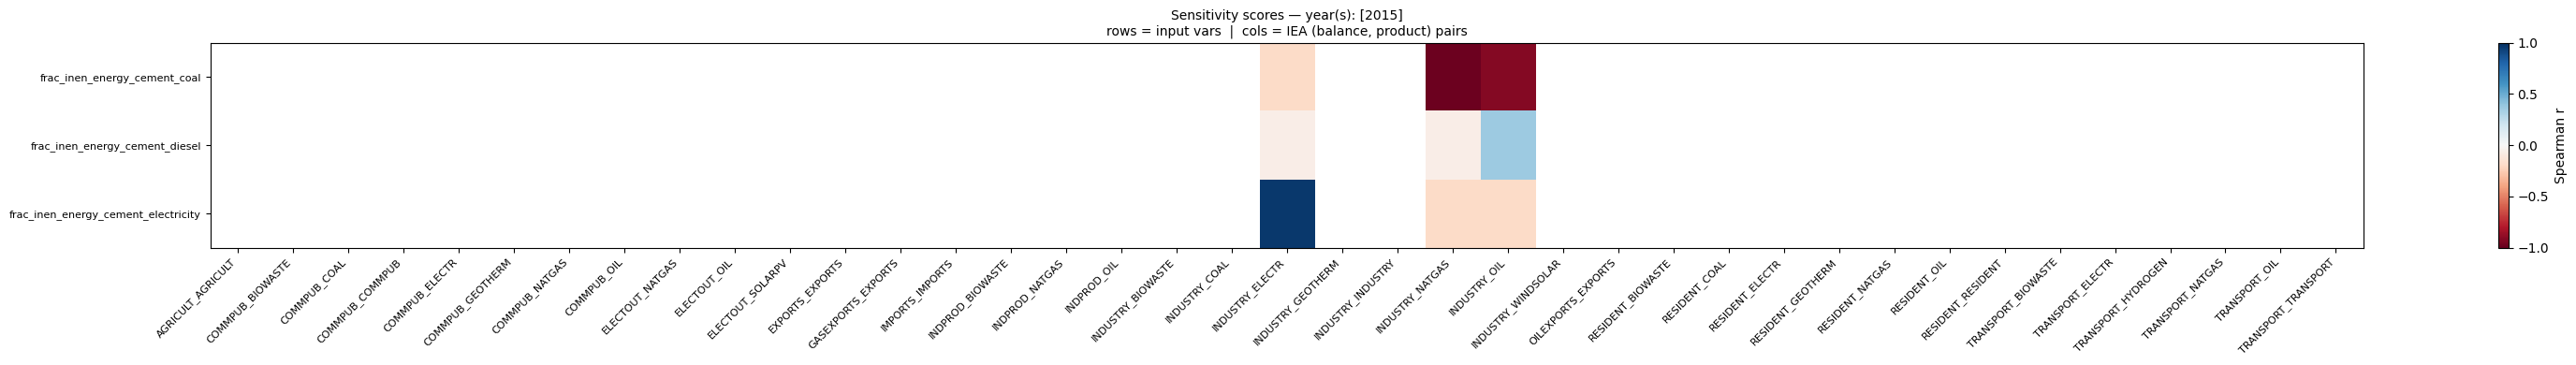

In [50]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(max(8, len(scores.columns)*0.8), max(4, len(scores)*0.6)))
im = ax.imshow(scores.values, cmap="RdBu", vmin=-1, vmax=1, aspect="auto")

ax.set_xticks(range(len(scores.columns)))
ax.set_xticklabels(scores.columns, rotation=45, ha="right", fontsize=8)
ax.set_yticks(range(len(scores.index)))
ax.set_yticklabels(scores.index, fontsize=8)

plt.colorbar(im, ax=ax, label="Spearman r")
ax.set_title(f"Sensitivity scores — year(s): {TARGET_YEARS}\n"
             f"rows = input vars  |  cols = IEA (balance, product) pairs",
             fontsize=10)
fig.tight_layout()
plt.show()

In [51]:
# Rank input variables by their maximum absolute influence across all IEA pairs
top_vars = scores.abs().max(axis=1).sort_values(ascending=False)
print("Most influential input variables (max |Spearman r| across all IEA pairs):")
display(top_vars.to_frame(name="max_abs_r"))

Most influential input variables (max |Spearman r| across all IEA pairs):


,max_abs_r
frac_inen_energy_cement_coal,0.977719
frac_inen_energy_cement_electricity,0.963986
frac_inen_energy_cement_diesel,0.365570


---
## 8. Linearity check

`linearity_check()` produces a two-panel figure:
- **Left**: scatter of input scale factor vs IEA relative error, with a linear fit and R2.
- **Right**: residuals from that fit.

**How to interpret:**
- R2 =~ 1, random residuals -> relationship is linear -> **linear calibration is sufficient**
- Curved pattern or R2 << 1 -> nonlinear -> **use an optimiser or a surrogate model**

Run it for each variable–IEA pair combination we care about.

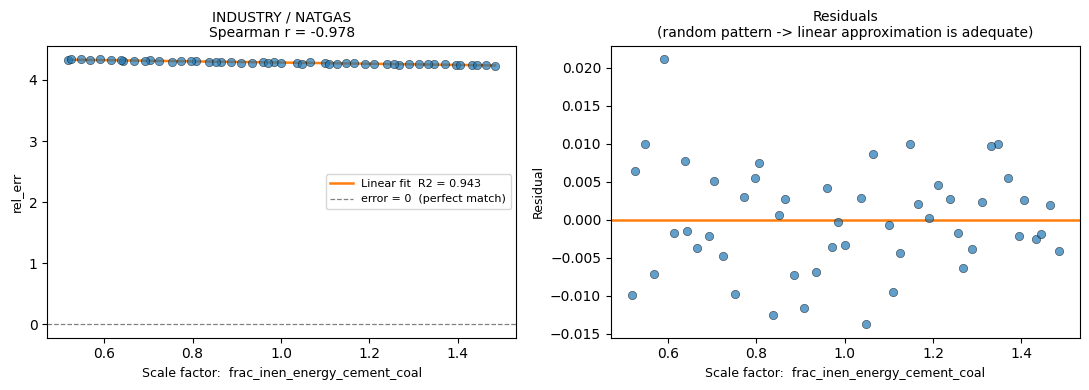

In [52]:
# Check linearity for one variable and one IEA target using the LHS result
# (smoother x-axis coverage than OAT)
fig = linearity_check(
    result           = result_lhs_multi,
    var_column       = "frac_inen_energy_cement_coal",   # x-axis
    iea_balance_code = "INDUSTRY",                       # IEA balance to check
    iea_product_code = "NATGAS",                         # IEA product to check
    years            = TARGET_YEARS,
)
plt.show()

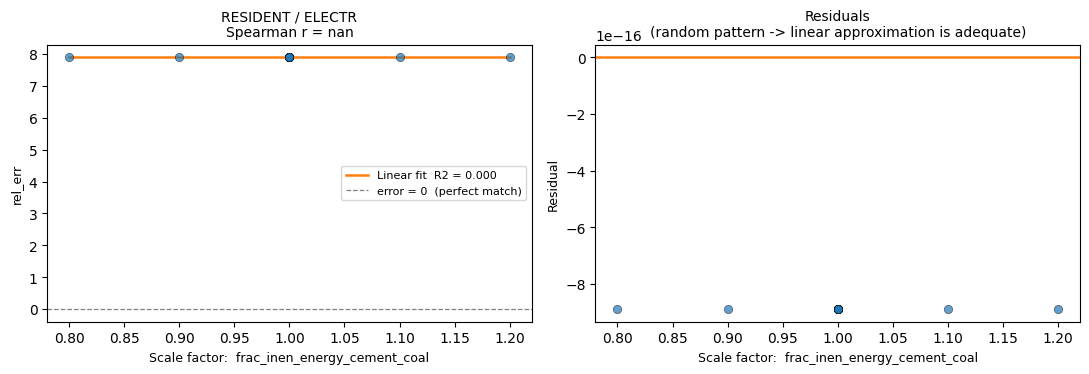

In [53]:
# WE can also run it on an OAT result — each level becomes one point on the plot
fig = linearity_check(
    result           = result_oat_multi,
    var_column       = "frac_inen_energy_cement_coal",
    iea_balance_code = "RESIDENT",
    iea_product_code = "ELECTR",
    years            = TARGET_YEARS,
)
plt.show()

Variables with |r| > 0.3 for any IEA pair: ['frac_inen_energy_cement_coal', 'frac_inen_energy_cement_electricity', 'frac_inen_energy_cement_diesel']


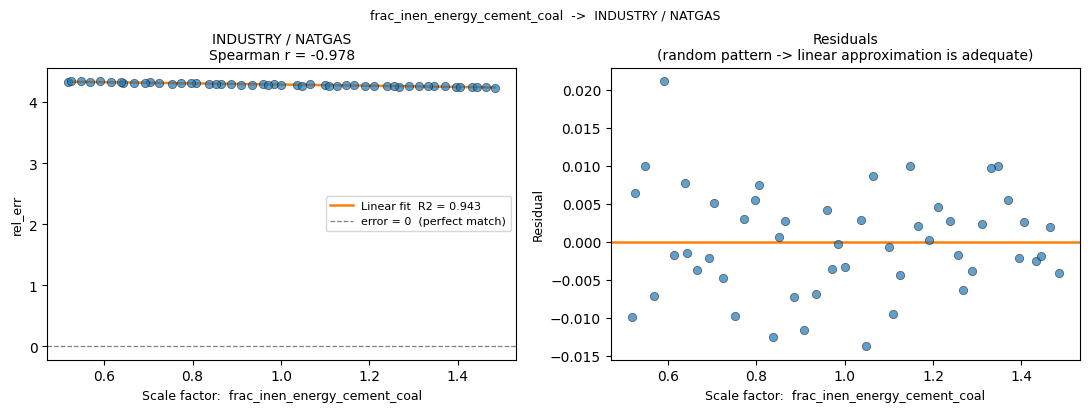

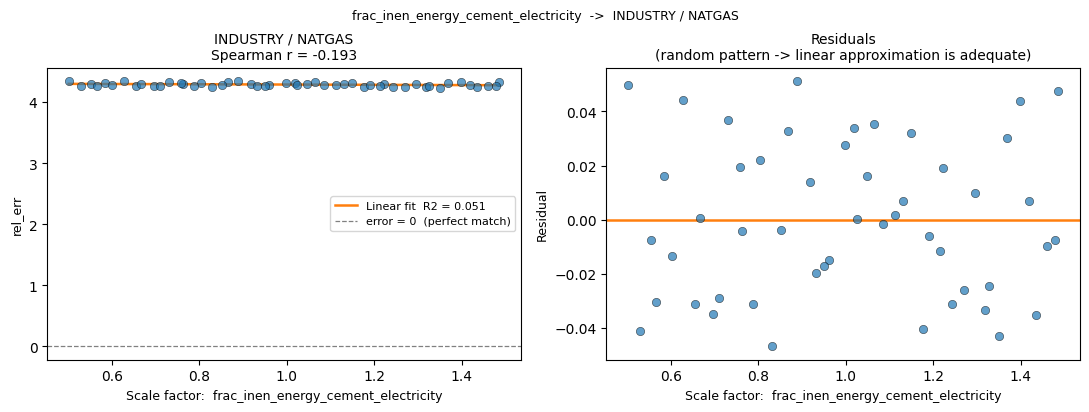

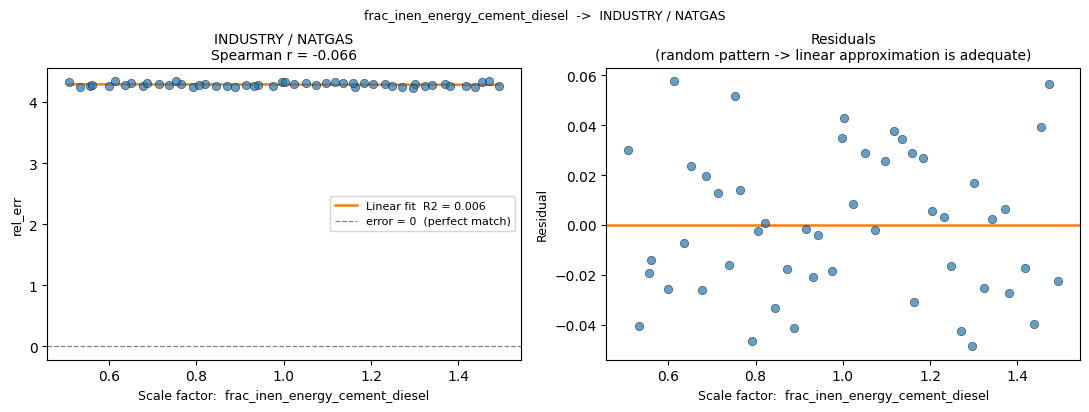

In [54]:
# Loop over all influential variables for a specific IEA pair
TARGET_BALANCE = "INDUSTRY"
TARGET_PRODUCT = "NATGAS"

influential = top_vars[top_vars > 0.3].index.tolist()
print(f"Variables with |r| > 0.3 for any IEA pair: {influential}")

for var in influential:
    try:
        fig = linearity_check(
            result           = result_lhs_multi,
            var_column       = var,
            iea_balance_code = TARGET_BALANCE,
            iea_product_code = TARGET_PRODUCT,
            years            = TARGET_YEARS,
        )
        fig.suptitle(f"{var}  ->  {TARGET_BALANCE} / {TARGET_PRODUCT}", fontsize=9, y=1.02)
        plt.show()
    except ValueError as e:
        print(f"  skipped {var}: {e}")

---
## 9. Next steps

### If the relationship is linear
Use the sensitivity matrix to set up a **linear system** calibration:
- The Spearman scores tell which inputs to touch and in which direction.
- `_lib.scale_inputs_single_value()` already does a one-shot linear rescaling
  for a single (input, output, target) triple.
- For multiple simultaneous targets, set up a small linear system A.Delta x = Delta y
  where A comes from the finite-difference sensitivities.

### If the relationship is nonlinear
Two options:

1. **Optimisation directly on the model** — use `scipy.optimize.minimize`
   (or a gradient-free method like Nelder-Mead) with a cost function built
   from `IEACrosswalk.build_comparison()`. Expensive per evaluation but exact.

2. **Surrogate model** — the LHS result is already the training data:
   `X_train` (input scale factors) and `Y_train` (IEA ratios per run).
   Fit a fast surrogate (Gaussian process, random forest, or polynomial) and
   optimise against the surrogate instead of the full model.

### Simplex-constrained variables
Simplex-aware perturbation is fully implemented.  Setting `is_simplex_group=True`
on any `VariableSpec` activates simultaneous renormalization: all scale factors
for the same simplex constraint are applied at once and the row sum is preserved
exactly at 1.0.

For calibration (not just sensitivity), use `_lib.shift_fuels_based_on_single_point()`
which shifts toward a specific target fuel while reading and writing the actual
model-variable objects — better suited for iterative convergence than the
scale-factor approach used here.